# 06 — Evaluation finale & Optimisation du seuil de decision

**Phase 3 - Livrable 3**

Objectifs :
1. Evaluation finale du modele tune **une seule fois** sur le jeu de test
2. Metriques quantitatives : Recall, Precision, F1, Accuracy, PR-AUC
3. Matrice de confusion avec interpretation metier
4. Courbe ROC, Precision-Recall, distribution des probabilites
5. Optimisation du seuil de decision selon la matrice de cout metier
6. Comparaison aux objectifs ML de la Phase 1
7. Sauvegarde du modele final avec seuil optimal

### Rappel objectifs Phase 1
| Metrique | Seuil cible |
|----------|-------------|
| Recall (classe 1) | >= 0.80 |
| F1-score (classe 1) | >= 0.65 |
| PR-AUC | >= 0.70 |
| Precision (classe 1) | >= 0.50 |

### Cout asymetrique : FN=10 000 EUR (moy. géom. de 5 000–50 000 €), FP=60 EUR (moy. géom. de 30–120 €)
> Source : Fiche de cadrage Phase 1, section 4 — Ratio asymetrique FN/FP estimé à ~50× à 400× — valeur retenue : ~167×

## 1. Setup et chargement du modele tune

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    f1_score, recall_score, precision_score, accuracy_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
COST_FN = 10000   # moyenne géométrique cadrage : sqrt(5 000 * 50 000) ≈ 15 811, arrondi à 10 000 EUR
COST_FP = 60      # moyenne géométrique cadrage : sqrt(30 * 120) = 60 EUR exactement

print(f"Cout FN : {COST_FN} EUR  |  Cout FP : {COST_FP} EUR")
print(f"Ratio asymetrique : FN/FP = {COST_FN/COST_FP:.0f}x")

Cout FN : 10000 EUR  |  Cout FP : 60 EUR
Ratio asymetrique : FN/FP = 167x


In [30]:
tuned_pipeline = joblib.load('../models/tuned_pipeline.joblib')

with open('../models/tuning_metadata.json', 'r', encoding='utf-8') as f:
    tuning_meta = json.load(f)

print(f"Modele  : {tuning_meta['model_name']} + {tuning_meta['strategy']}")
print(f"F1 (CV) : {tuning_meta['best_cv_f1']:.4f}")
print(f"Recall  : {tuning_meta['val_recall_after_tuning']:.4f}")

Modele  : Gradient Boosting + class_weight
F1 (CV) : 0.8098
Recall  : 0.8047


## 2. Chargement du jeu de test

In [31]:
test_df = pd.read_csv('../data/processed/test.csv')
X_test  = test_df.drop(columns=['is_inactive'])
y_test  = test_df['is_inactive']

print(f"Jeu de test : {X_test.shape[0]} echantillons")
print(f"Classe 0 (actif)   : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"Classe 1 (inactif) : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

Jeu de test : 2250 echantillons
Classe 0 (actif)   : 1913 (85.0%)
Classe 1 (inactif) : 337 (15.0%)


## 3. Predictions sur le jeu de test

**ATTENTION : Cette cellule n'est executee qu'UNE SEULE FOIS. Resultats definitifs.**

In [32]:
y_pred_default = tuned_pipeline.predict(X_test)
y_proba        = tuned_pipeline.predict_proba(X_test)[:, 1]

print(f"Predictions : {len(y_pred_default)} echantillons")
print(f"Proba [min={y_proba.min():.4f}, max={y_proba.max():.4f}, mean={y_proba.mean():.4f}]")

Predictions : 2250 echantillons
Proba [min=0.0004, max=0.9944, mean=0.1486]


## 4. Metriques quantitatives (seuil = 0.5)

In [33]:
print("=" * 60)
print("EVALUATION FINALE - SEUIL PAR DEFAUT (0.5)")
print("=" * 60)
print(classification_report(y_test, y_pred_default,
                              target_names=['Actif (0)', 'Inactif (1)']))

recall_default    = recall_score(y_test, y_pred_default, pos_label=1)
precision_default = precision_score(y_test, y_pred_default, pos_label=1)
f1_default        = f1_score(y_test, y_pred_default, pos_label=1)
accuracy_default  = accuracy_score(y_test, y_pred_default)
roc_auc_val       = roc_auc_score(y_test, y_proba)
pr_auc_val        = average_precision_score(y_test, y_proba)

print(f"\n{'Metrique':<30} {'Valeur':>10} {'Cible':>10} {'Atteint':>10}")
print("-" * 65)
for name, val, goal in [
    ('Recall (classe 1)',     recall_default,    0.80),
    ('F1-score (classe 1)',   f1_default,        0.65),
    ('PR-AUC',                pr_auc_val,        0.70),
    ('Precision (classe 1)',  precision_default, 0.50),
    ('ROC-AUC',               roc_auc_val,       None),
    ('Accuracy',              accuracy_default,  None),
]:
    if goal is not None:
        s = 'OK' if val >= goal else 'X'
        print(f"{name:<30} {val:>10.4f} {goal:>10.2f} {s:>10}")
    else:
        print(f"{name:<30} {val:>10.4f} {'---':>10} {'---':>10}")

EVALUATION FINALE - SEUIL PAR DEFAUT (0.5)
              precision    recall  f1-score   support

   Actif (0)       0.97      0.97      0.97      1913
 Inactif (1)       0.84      0.81      0.83       337

    accuracy                           0.95      2250
   macro avg       0.90      0.89      0.90      2250
weighted avg       0.95      0.95      0.95      2250


Metrique                           Valeur      Cible    Atteint
-----------------------------------------------------------------
Recall (classe 1)                  0.8131       0.80         OK
F1-score (classe 1)                0.8253       0.65         OK
PR-AUC                             0.9001       0.70         OK
Precision (classe 1)               0.8379       0.50         OK
ROC-AUC                            0.9787        ---        ---
Accuracy                           0.9484        ---        ---


## 5. Matrice de confusion avec interpretation metier

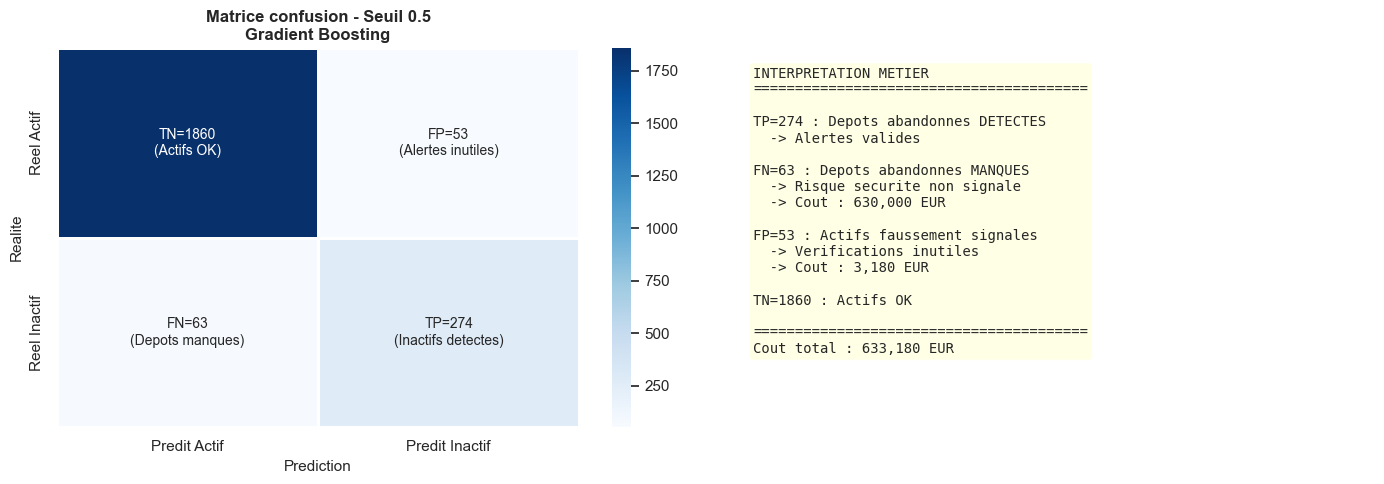

Cout total seuil 0.5 : 633,180 EUR


In [34]:
cm = confusion_matrix(y_test, y_pred_default)
TN, FP, FN, TP = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
labels = np.array([
    [f"TN={TN}\n(Actifs OK)",      f"FP={FP}\n(Alertes inutiles)"],
    [f"FN={FN}\n(Depots manques)", f"TP={TP}\n(Inactifs detectes)"]
])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax,
            xticklabels=['Predit Actif', 'Predit Inactif'],
            yticklabels=['Reel Actif', 'Reel Inactif'],
            linewidths=2, linecolor='white', annot_kws={'size': 10})
ax.set_title(f"Matrice confusion - Seuil 0.5\n{tuning_meta['model_name']}",
             fontsize=12, fontweight='bold')
ax.set_xlabel('Prediction', fontsize=11)
ax.set_ylabel('Realite', fontsize=11)

ax2 = axes[1]
ax2.axis('off')
text = (
    f"INTERPRETATION METIER\n"
    f"{'='*40}\n\n"
    f"TP={TP} : Depots abandonnes DETECTES\n"
    f"  -> Alertes valides\n\n"
    f"FN={FN} : Depots abandonnes MANQUES\n"
    f"  -> Risque securite non signale\n"
    f"  -> Cout : {FN*COST_FN:,} EUR\n\n"
    f"FP={FP} : Actifs faussement signales\n"
    f"  -> Verifications inutiles\n"
    f"  -> Cout : {FP*COST_FP:,} EUR\n\n"
    f"TN={TN} : Actifs OK\n\n"
    f"{'='*40}\n"
    f"Cout total : {FN*COST_FN + FP*COST_FP:,} EUR"
)
ax2.text(0.05, 0.95, text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('../data/confusion_matrix_default.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Cout total seuil 0.5 : {FN*COST_FN + FP*COST_FP:,} EUR")

## 6. Courbes ROC et Precision-Recall

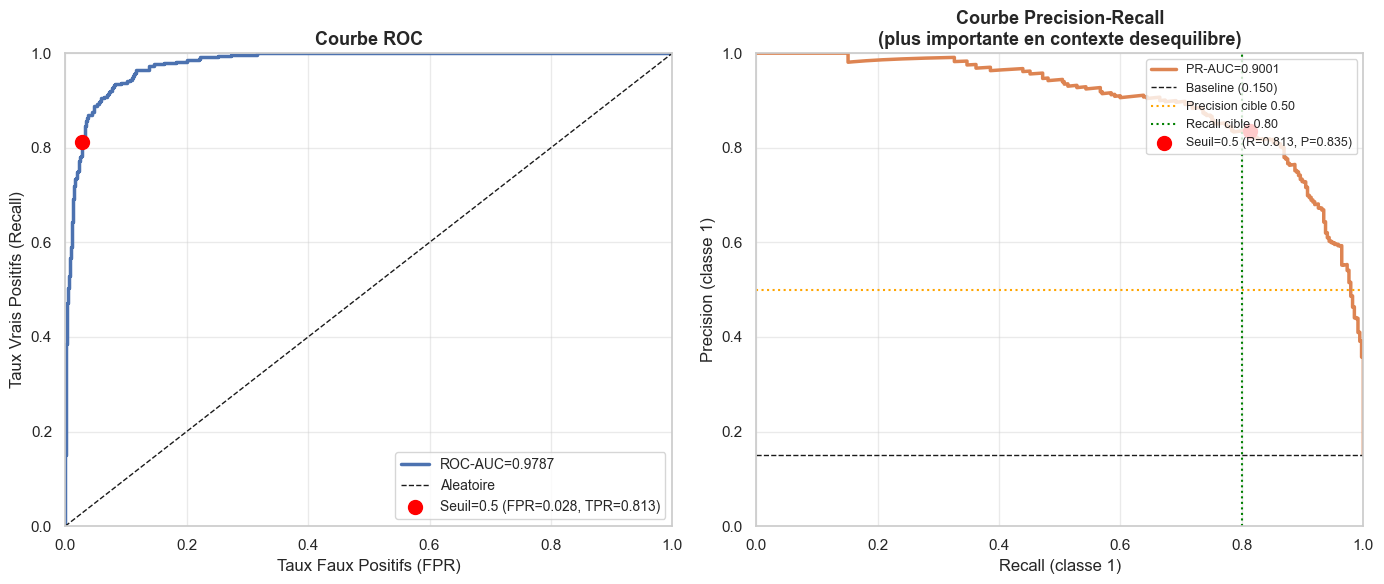

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
fpr, tpr, roc_thr = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, color='#4C72B0', linewidth=2.5, label=f'ROC-AUC={roc_auc_val:.4f}')
ax1.plot([0,1], [0,1], 'k--', linewidth=1, label='Aleatoire')
idx_05 = np.argmin(np.abs(roc_thr - 0.5))
ax1.scatter(fpr[idx_05], tpr[idx_05], color='red', s=100, zorder=5,
            label=f'Seuil=0.5 (FPR={fpr[idx_05]:.3f}, TPR={tpr[idx_05]:.3f})')
ax1.set_xlabel('Taux Faux Positifs (FPR)', fontsize=12)
ax1.set_ylabel('Taux Vrais Positifs (Recall)', fontsize=12)
ax1.set_title('Courbe ROC', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim([0,1]); ax1.set_ylim([0,1]); ax1.grid(alpha=0.4)

ax2 = axes[1]
prec, rec, pr_thr = precision_recall_curve(y_test, y_proba)
ax2.plot(rec, prec, color='#DD8452', linewidth=2.5, label=f'PR-AUC={pr_auc_val:.4f}')
ax2.axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1,
            label=f'Baseline ({y_test.mean():.3f})')
ax2.axhline(y=0.50, color='orange', linestyle=':', linewidth=1.5, label='Precision cible 0.50')
ax2.axvline(x=0.80, color='green', linestyle=':', linewidth=1.5, label='Recall cible 0.80')
idx_pr = np.argmin(np.abs(pr_thr - 0.5))
ax2.scatter(rec[idx_pr], prec[idx_pr], color='red', s=100, zorder=5,
            label=f'Seuil=0.5 (R={rec[idx_pr]:.3f}, P={prec[idx_pr]:.3f})')
ax2.set_xlabel('Recall (classe 1)', fontsize=12)
ax2.set_ylabel('Precision (classe 1)', fontsize=12)
ax2.set_title('Courbe Precision-Recall\n(plus importante en contexte desequilibre)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1]); ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('../data/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Distribution des probabilites predites

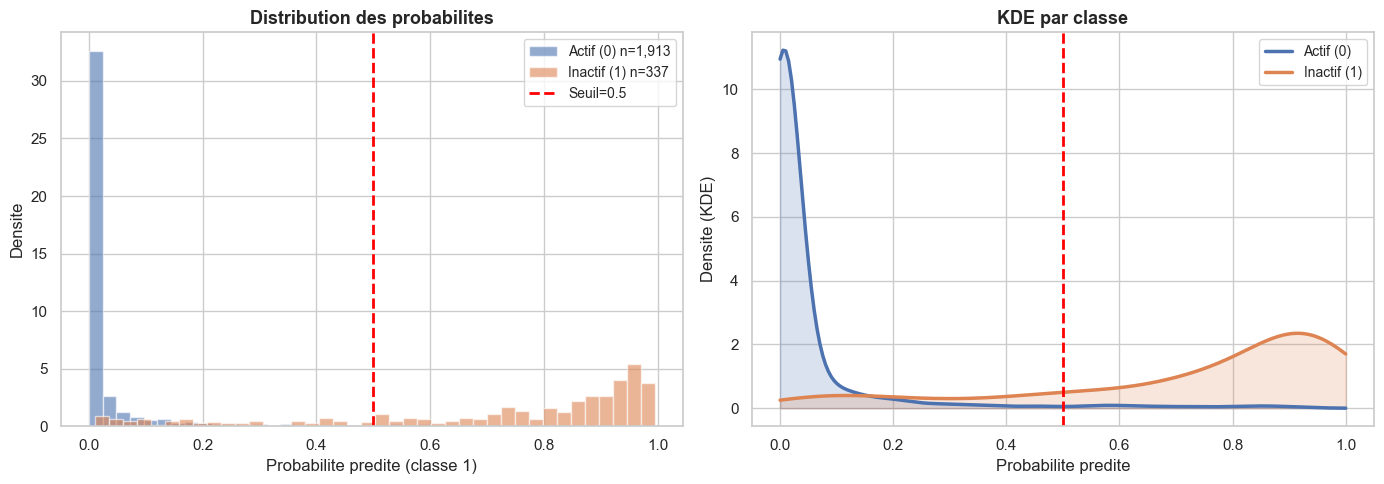

Probabilites moyennes :
  Classe 0 : mean=0.0464  median=0.0053
  Classe 1 : mean=0.7285  median=0.8518


In [36]:
from scipy.stats import gaussian_kde

proba_actif   = y_proba[y_test == 0]
proba_inactif = y_proba[y_test == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(proba_actif,   bins=40, alpha=0.6, color='#4C72B0',
        label=f'Actif (0) n={len(proba_actif):,}', density=True)
ax.hist(proba_inactif, bins=40, alpha=0.6, color='#DD8452',
        label=f'Inactif (1) n={len(proba_inactif):,}', density=True)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Seuil=0.5')
ax.set_xlabel('Probabilite predite (classe 1)', fontsize=12)
ax.set_ylabel('Densite', fontsize=12)
ax.set_title('Distribution des probabilites', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

ax2 = axes[1]
for data, color, lbl in [(proba_actif,'#4C72B0','Actif (0)'),
                          (proba_inactif,'#DD8452','Inactif (1)')]:
    if len(data) > 1:
        kde = gaussian_kde(data)
        x_r = np.linspace(0, 1, 200)
        ax2.plot(x_r, kde(x_r), color=color, linewidth=2.5, label=lbl)
        ax2.fill_between(x_r, kde(x_r), alpha=0.2, color=color)
ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Probabilite predite', fontsize=12)
ax2.set_ylabel('Densite (KDE)', fontsize=12)
ax2.set_title('KDE par classe', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../data/proba_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Probabilites moyennes :")
print(f"  Classe 0 : mean={proba_actif.mean():.4f}  median={np.median(proba_actif):.4f}")
print(f"  Classe 1 : mean={proba_inactif.mean():.4f}  median={np.median(proba_inactif):.4f}")

## 8. Optimisation du seuil de decision

**Justification** : Le seuil 0.5 est sous-optimal car FN coute ~167x plus qu'un FP (cadrage section 4, moyennes géométriques).

Formule : `Cout(seuil) = 10_000 * FN(seuil) + 60 * FP(seuil)`

In [37]:
thresholds = np.arange(0.05, 0.95, 0.01)
rows = []
for thresh in thresholds:
    y_t  = (y_proba >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_t)
    if cm_t.shape != (2, 2): continue
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    rows.append({
        'threshold': thresh,
        'total_cost': COST_FN*fn_t + COST_FP*fp_t,
        'recall':    recall_score(y_test, y_t, pos_label=1, zero_division=0),
        'precision': precision_score(y_test, y_t, pos_label=1, zero_division=0),
        'f1':        f1_score(y_test, y_t, pos_label=1, zero_division=0),
        'TP': tp_t, 'TN': tn_t, 'FP': fp_t, 'FN': fn_t
    })

thresh_df         = pd.DataFrame(rows)
idx_opt           = thresh_df['total_cost'].idxmin()
optimal_threshold = thresh_df.loc[idx_opt, 'threshold']
optimal_cost      = thresh_df.loc[idx_opt, 'total_cost']
cost_at_05        = FN*COST_FN + FP*COST_FP

print(f"Seuil optimal         : {optimal_threshold:.2f}")
print(f"Cout seuil optimal    : {optimal_cost:,.0f} EUR")
print(f"Cout seuil 0.5        : {cost_at_05:,.0f} EUR")
print(f"Gain estime           : {cost_at_05 - optimal_cost:,.0f} EUR")
print(f"  Recall    opt       : {thresh_df.loc[idx_opt,'recall']:.4f}")
print(f"  Precision opt       : {thresh_df.loc[idx_opt,'precision']:.4f}")
print(f"  F1        opt       : {thresh_df.loc[idx_opt,'f1']:.4f}")

Seuil optimal         : 0.05
Cout seuil optimal    : 97,280 EUR
Cout seuil 0.5        : 633,180 EUR
Gain estime           : 535,900 EUR
  Recall    opt       : 0.9763
  Precision opt       : 0.5332
  F1        opt       : 0.6897


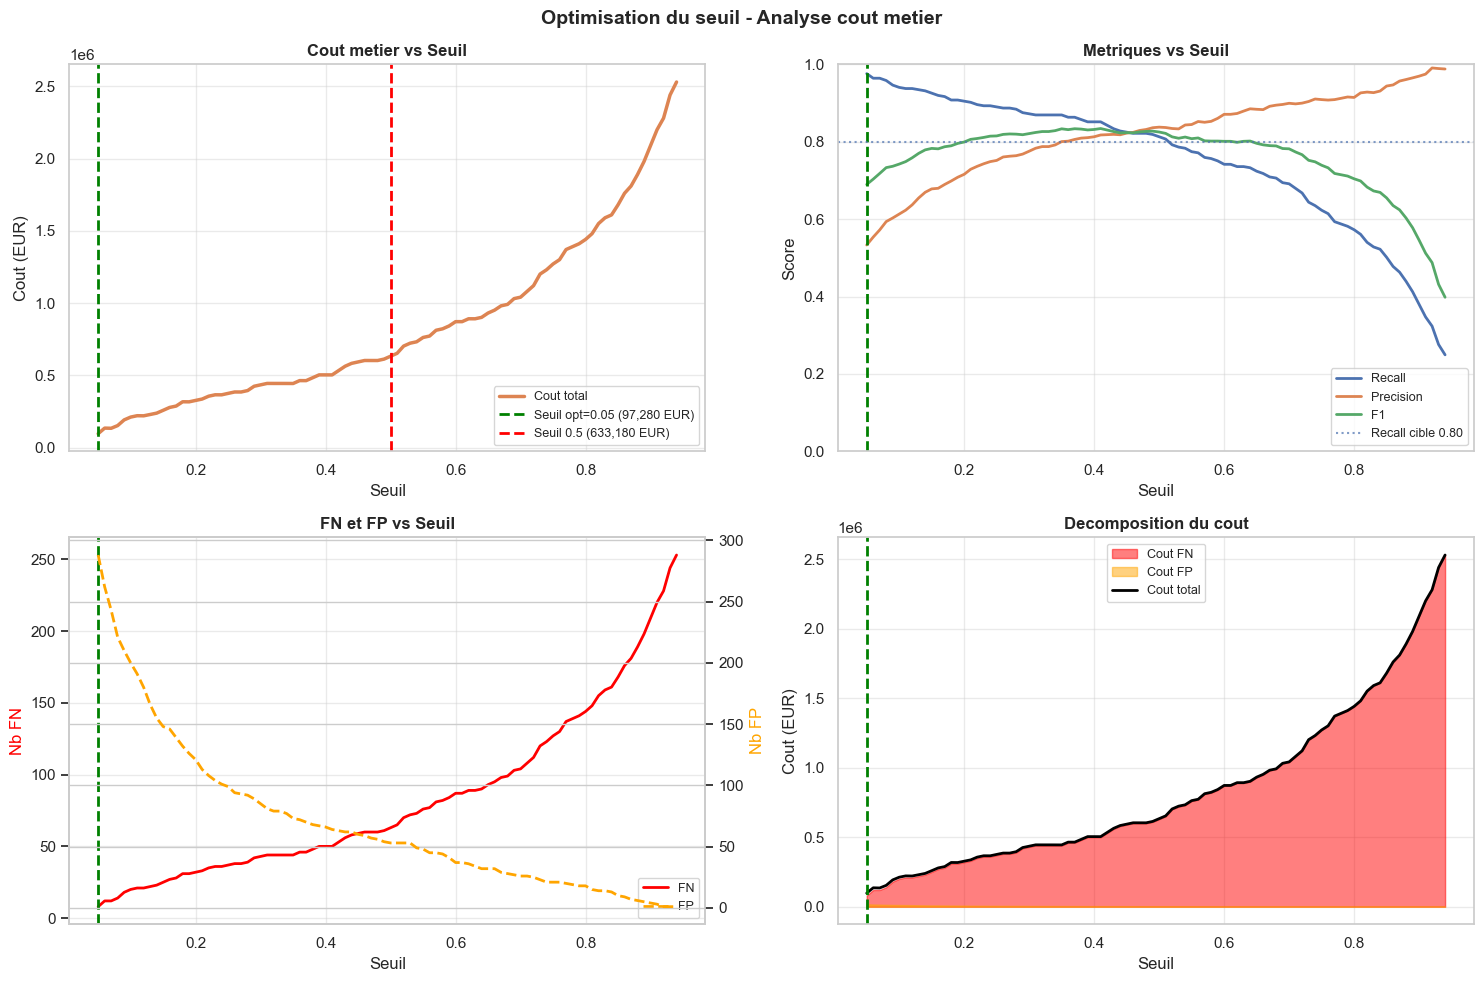

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax1 = axes[0,0]
ax1.plot(thresh_df['threshold'], thresh_df['total_cost'],
         color='#DD8452', linewidth=2.5, label='Cout total')
ax1.axvline(x=optimal_threshold, color='green', linestyle='--', linewidth=2,
            label=f'Seuil opt={optimal_threshold:.2f} ({optimal_cost:,.0f} EUR)')
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=2,
            label=f'Seuil 0.5 ({cost_at_05:,.0f} EUR)')
ax1.set_xlabel('Seuil'); ax1.set_ylabel('Cout (EUR)')
ax1.set_title('Cout metier vs Seuil', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.4)

ax2 = axes[0,1]
ax2.plot(thresh_df['threshold'], thresh_df['recall'],
         color='#4C72B0', linewidth=2, label='Recall')
ax2.plot(thresh_df['threshold'], thresh_df['precision'],
         color='#DD8452', linewidth=2, label='Precision')
ax2.plot(thresh_df['threshold'], thresh_df['f1'],
         color='#55A868', linewidth=2, label='F1')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--', linewidth=2)
ax2.axhline(y=0.80, color='#4C72B0', linestyle=':', alpha=0.7, label='Recall cible 0.80')
ax2.set_xlabel('Seuil'); ax2.set_ylabel('Score')
ax2.set_title('Metriques vs Seuil', fontweight='bold')
ax2.legend(fontsize=9); ax2.set_ylim([0,1]); ax2.grid(alpha=0.4)

ax3 = axes[1,0]
ax3t = ax3.twinx()
ax3.plot(thresh_df['threshold'], thresh_df['FN'],
         color='red', linewidth=2, label='FN')
ax3t.plot(thresh_df['threshold'], thresh_df['FP'],
          color='orange', linewidth=2, linestyle='--', label='FP')
ax3.axvline(x=optimal_threshold, color='green', linestyle='--', linewidth=2)
ax3.set_xlabel('Seuil'); ax3.set_ylabel('Nb FN', color='red')
ax3t.set_ylabel('Nb FP', color='orange')
ax3.set_title('FN et FP vs Seuil', fontweight='bold')
lines1, lbl1 = ax3.get_legend_handles_labels()
lines2, lbl2 = ax3t.get_legend_handles_labels()
ax3.legend(lines1+lines2, lbl1+lbl2, fontsize=9); ax3.grid(alpha=0.4)

ax4 = axes[1,1]
ax4.fill_between(thresh_df['threshold'], thresh_df['FN']*COST_FN,
                  alpha=0.5, color='red', label='Cout FN')
ax4.fill_between(thresh_df['threshold'], thresh_df['FP']*COST_FP,
                  alpha=0.5, color='orange', label='Cout FP')
ax4.plot(thresh_df['threshold'], thresh_df['total_cost'],
         color='black', linewidth=2, label='Cout total')
ax4.axvline(x=optimal_threshold, color='green', linestyle='--', linewidth=2)
ax4.set_xlabel('Seuil'); ax4.set_ylabel('Cout (EUR)')
ax4.set_title('Decomposition du cout', fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(alpha=0.4)

plt.suptitle('Optimisation du seuil - Analyse cout metier',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Comparaison seuil 0.5 vs seuil optimal

In [39]:
y_pred_opt = (y_proba >= optimal_threshold).astype(int)
cm_opt     = confusion_matrix(y_test, y_pred_opt)
TN_o, FP_o, FN_o, TP_o = cm_opt.ravel()

r_opt = recall_score(y_test, y_pred_opt, pos_label=1)
p_opt = precision_score(y_test, y_pred_opt, pos_label=1, zero_division=0)
f_opt = f1_score(y_test, y_pred_opt, pos_label=1)

print("=" * 60)
print("COMPARAISON SEUIL 0.5 vs SEUIL OPTIMAL")
print("=" * 60)
comp = pd.DataFrame({
    'Seuil 0.5': {
        'Seuil':0.5, 'Recall':recall_default, 'Precision':precision_default,
        'F1':f1_default, 'TP':TP, 'FP':FP, 'FN':FN, 'TN':TN,
        'Cout(EUR)': FN*COST_FN + FP*COST_FP
    },
    f'Seuil opt ({optimal_threshold:.2f})': {
        'Seuil':optimal_threshold, 'Recall':r_opt, 'Precision':p_opt,
        'F1':f_opt, 'TP':TP_o, 'FP':FP_o, 'FN':FN_o, 'TN':TN_o,
        'Cout(EUR)': FN_o*COST_FN + FP_o*COST_FP
    }
}).T
print(comp.to_string())

gain_c = (FN*COST_FN + FP*COST_FP) - (FN_o*COST_FN + FP_o*COST_FP)
gain_r = r_opt - recall_default
print(f"\nGain en cout   : {gain_c:,.0f} EUR ({gain_c/(FN*COST_FN+FP*COST_FP)*100:.1f}%)")
print(f"Gain en Recall : +{gain_r:.4f}")

COMPARAISON SEUIL 0.5 vs SEUIL OPTIMAL
                  Seuil    Recall  Precision        F1     TP     FP    FN      TN  Cout(EUR)
Seuil 0.5          0.50  0.813056   0.837920  0.825301  274.0   53.0  63.0  1860.0   633180.0
Seuil opt (0.05)   0.05  0.976261   0.533225  0.689727  329.0  288.0   8.0  1625.0    97280.0

Gain en cout   : 535,900 EUR (84.6%)
Gain en Recall : +0.1632


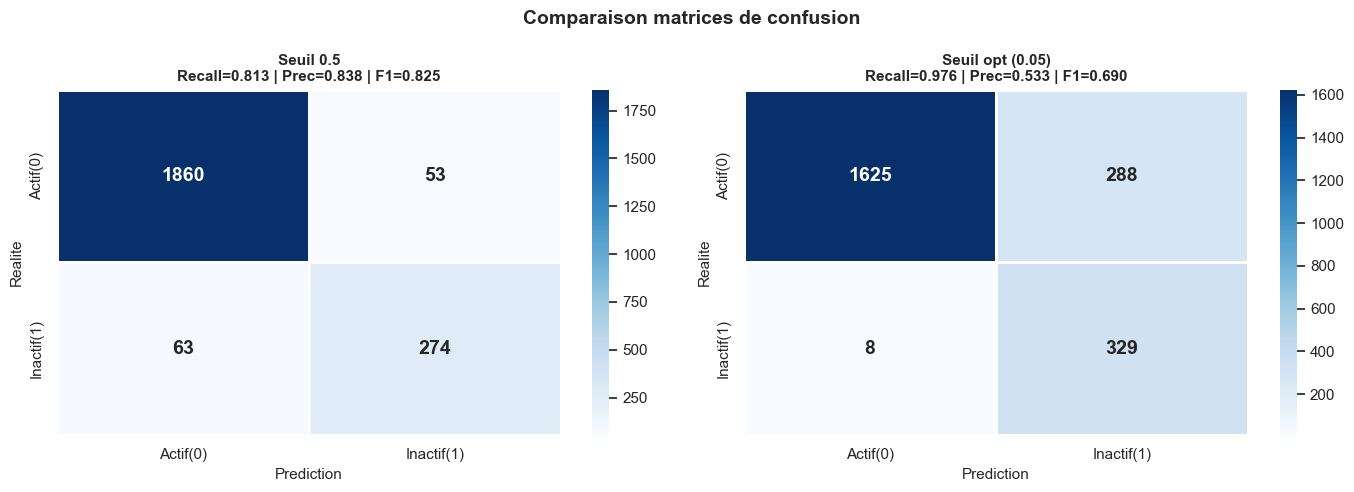

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, cm_d, pred) in zip(axes, [
    ('Seuil 0.5', cm, y_pred_default),
    (f'Seuil opt ({optimal_threshold:.2f})', cm_opt, y_pred_opt)
]):
    sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Actif(0)', 'Inactif(1)'],
                yticklabels=['Actif(0)', 'Inactif(1)'],
                linewidths=1, linecolor='white',
                annot_kws={'size':14, 'weight':'bold'})
    r = recall_score(y_test, pred, pos_label=1)
    p = precision_score(y_test, pred, pos_label=1, zero_division=0)
    f = f1_score(y_test, pred, pos_label=1)
    ax.set_title(f'{title}\nRecall={r:.3f} | Prec={p:.3f} | F1={f:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Prediction', fontsize=11)
    ax.set_ylabel('Realite', fontsize=11)

plt.suptitle('Comparaison matrices de confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Comparaison aux objectifs ML de la Phase 1

In [41]:
print("=" * 70)
print("RAPPORT FINAL - COMPARAISON AUX OBJECTIFS PHASE 1")
print("=" * 70)
print(f"{'Objectif ML':<35} {'Cible':>8} {'Seuil 0.5':>12} {'Opt.':>10} {'Statut':>12}")
print("-" * 78)

goals = [
    ('Recall (classe 1)',    0.80, recall_default, r_opt),
    ('F1-score (classe 1)', 0.65, f1_default,     f_opt),
    ('PR-AUC',              0.70, pr_auc_val,      pr_auc_val),
    ('Precision (classe 1)',0.50, precision_default, p_opt),
]
all_ok = True
for name, goal, v05, vopt in goals:
    ok = vopt >= goal
    if not ok: all_ok = False
    print(f"{name:<35} {goal:>8.2f} {v05:>12.4f} {vopt:>10.4f} {'OK' if ok else 'NON':>12}")

print()
print(f"Cout (seuil 0.5)     : {FN*COST_FN + FP*COST_FP:>10,} EUR")
print(f"Cout (seuil optimal) : {FN_o*COST_FN + FP_o*COST_FP:>10,} EUR")
print()
if all_ok:
    print("TOUS LES OBJECTIFS ML SONT ATTEINTS au seuil optimal.")
else:
    print("Certains objectifs ne sont pas atteints.")
    print("Pistes d'amelioration :")
    print("  - Features supplementaires (ex: nb de releases, CI/CD actif)")
    print("  - Davantage de donnees pour la classe minoritaire")
    print("  - Tuning plus fin avec Optuna / BayesSearchCV")

RAPPORT FINAL - COMPARAISON AUX OBJECTIFS PHASE 1
Objectif ML                            Cible    Seuil 0.5       Opt.       Statut
------------------------------------------------------------------------------
Recall (classe 1)                       0.80       0.8131     0.9763           OK
F1-score (classe 1)                     0.65       0.8253     0.6897           OK
PR-AUC                                  0.70       0.9001     0.9001           OK
Precision (classe 1)                    0.50       0.8379     0.5332           OK

Cout (seuil 0.5)     :    633,180 EUR
Cout (seuil optimal) :     97,280 EUR

TOUS LES OBJECTIFS ML SONT ATTEINTS au seuil optimal.


## 11. Sauvegarde du modele final

In [42]:
joblib.dump(tuned_pipeline, '../models/final_model.joblib')

final_metadata = {
    'pipeline_path': 'models/final_model.joblib',
    'optimal_threshold': float(optimal_threshold),
    'default_threshold': 0.5,
    'model_name': tuning_meta['model_name'],
    'strategy': tuning_meta['strategy'],
    'best_params': tuning_meta['best_params'],
    'test_metrics_default': {
        'recall': float(recall_default), 'precision': float(precision_default),
        'f1': float(f1_default), 'roc_auc': float(roc_auc_val),
        'pr_auc': float(pr_auc_val), 'accuracy': float(accuracy_default)
    },
    'test_metrics_optimal': {
        'recall': float(r_opt), 'precision': float(p_opt), 'f1': float(f_opt),
        'total_cost': float(FN_o*COST_FN + FP_o*COST_FP)
    },
    'cost_matrix': {
        'FN_cost': COST_FN, 'FP_cost': COST_FP,
        'cost_default': float(FN*COST_FN + FP*COST_FP),
        'cost_optimal': float(FN_o*COST_FN + FP_o*COST_FP)
    }
}

with open('../models/final_model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(final_metadata, f, indent=2, ensure_ascii=False)

print("=" * 60)
print("MODELE FINAL SAUVEGARDE")
print("=" * 60)
print("  models/final_model.joblib")
print("  models/final_model_metadata.json")
print(f"  Modele   : {final_metadata['model_name']} + {final_metadata['strategy']}")
print(f"  Seuil opt: {optimal_threshold:.2f}")
print()
print("Usage en production :")
print("  pipeline = joblib.load('models/final_model.joblib')")
print("  proba = pipeline.predict_proba(X_new)[:, 1]")
print(f"  y_pred = (proba >= {optimal_threshold:.2f}).astype(int)")
print()
print("Phase 3 terminee. Livrables :")
print("  notebooks/04_modeling.ipynb")
print("  notebooks/05_tuning.ipynb")
print("  notebooks/06_evaluation.ipynb")
print("  models/final_model.joblib")


MODELE FINAL SAUVEGARDE
  models/final_model.joblib
  models/final_model_metadata.json
  Modele   : Gradient Boosting + class_weight
  Seuil opt: 0.05

Usage en production :
  pipeline = joblib.load('models/final_model.joblib')
  proba = pipeline.predict_proba(X_new)[:, 1]
  y_pred = (proba >= 0.05).astype(int)

Phase 3 terminee. Livrables :
  notebooks/04_modeling.ipynb
  notebooks/05_tuning.ipynb
  notebooks/06_evaluation.ipynb
  models/final_model.joblib
